# Transfer Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

CLASSES      = ["NORMAL", "PNEUMONIA"]
INPUT_SHAPE  = (224, 224, 3)
EPOCHS_FE    = 10   # Feature Extraction
EPOCHS_FT    = 10   # Fine-Tuning

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ─── CARGAR DATOS ──────────────────────────────────────────────────────────
from google.colab import drive
import zipfile

drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/chest_xray_npy.zip"
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall("/content/chest_xray_npy")

SAVE_DIR = "/content/chest_xray_npy"

X_train = np.load(f"{SAVE_DIR}/X_train.npy")
y_train = np.load(f"{SAVE_DIR}/y_train.npy")
X_val   = np.load(f"{SAVE_DIR}/X_val.npy")
y_val   = np.load(f"{SAVE_DIR}/y_val.npy")
X_test  = np.load(f"{SAVE_DIR}/X_test.npy")
y_test  = np.load(f"{SAVE_DIR}/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (5216, 224, 224) | Val: (16, 224, 224) | Test: (624, 224, 224)


### Preparación de datos para modelos preentrenados

Los modelos preentrenados en ImageNet esperan entrada de **3 canales (RGB)**. Las radiografías están en escala de grises (1 canal), por lo que replicamos el canal de grises tres veces. Esta práctica es habitual en imagen médica cuando se usan backbones de propósito general.

Además, cada modelo tiene su propia función de preprocesado (`preprocess_input`) que normaliza los píxeles al rango esperado por los pesos de ImageNet — es importante aplicarla correctamente para que los filtros preentrenados funcionen bien.

In [3]:
# ─── CONVERTIR ESCALA DE GRISES → RGB ─────────────────────────────────────
def to_rgb(X):
    """(N, H, W) o (N, H, W, 1) → (N, H, W, 3) replicando el canal."""
    if X.ndim == 3:
        X = X[..., np.newaxis]
    return np.repeat(X, 3, axis=-1).astype(np.float32)

X_train_rgb = to_rgb(X_train)
X_val_rgb   = to_rgb(X_val)
X_test_rgb  = to_rgb(X_test)

# preprocess_input de VGG16 y MobileNetV2 espera valores en [0, 255]
if X_train_rgb.max() <= 1.0:
    X_train_rgb = X_train_rgb * 255.0
    X_val_rgb   = X_val_rgb   * 255.0
    X_test_rgb  = X_test_rgb  * 255.0

print(f"RGB — Train: {X_train_rgb.shape} | Val: {X_val_rgb.shape} | Test: {X_test_rgb.shape}")
print(f"Rango de valores: [{X_train_rgb.min():.0f}, {X_train_rgb.max():.0f}]")

# ─── CLASS WEIGHTS ─────────────────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = dict(enumerate(cw))
print(f"Class weights: {class_weight_dict}")

RGB — Train: (5216, 224, 224, 3) | Val: (16, 224, 224, 3) | Test: (624, 224, 224, 3)
Rango de valores: [0, 255]
Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [4]:
# ─── HELPERS REUTILIZABLES ─────────────────────────────────────────────────

def make_generators(preprocess_fn, batch_size=32):
    """Crea generadores train/val con data augmentation y preprocesado del modelo."""
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.05,
        height_shift_range=0.05,
        fill_mode='nearest'
    ).flow(X_train_rgb, y_train, batch_size=batch_size)

    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    ).flow(X_val_rgb, y_val, batch_size=batch_size, shuffle=False)

    return train_gen, val_gen


def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (metric, label) in zip(axes,
            [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC-ROC')]):
        ax.plot(history.history[metric],          label='Train', color='steelblue')
        ax.plot(history.history[f'val_{metric}'], label='Val',   color='tomato')
        ax.set_title(label, fontsize=12)
        ax.set_xlabel('Época')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


results_summary = {}  # acumula métricas de todos los modelos para la comparación final

def evaluate_model(model, X_input, model_name):
    """Evaluación completa: classification report, AUC-ROC, sensibilidad,
    especificidad, matriz de confusión y curva ROC."""
    y_score = model.predict(X_input).flatten()
    y_pred  = (y_score > 0.5).astype(int)
    cm      = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    auc  = roc_auc_score(y_test, y_score)
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    print(f"\n{'='*55}")
    print(f"  EVALUACIÓN — {model_name} — TEST SET")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=CLASSES))
    print(f"AUC-ROC      : {auc:.4f}")
    print(f"Sensibilidad : {sens:.4f}  (Recall PNEUMONIA)")
    print(f"Especificidad: {spec:.4f}  (Recall NORMAL)")
    print(f"Falsos Negativos (enfermos no detectados): {fn}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', linewidths=0.5)
    axes[0].set_title(f"Confusión — {model_name}", fontsize=12)
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")
    RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1],
                                     name=model_name, color='steelblue')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f"ROC — {model_name}", fontsize=12)
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    results_summary[model_name] = {
        'accuracy': (tp + tn) / len(y_test),
        'auc': auc, 'sens': sens, 'spec': spec, 'fn': fn
    }
    return y_score

## VGG16

VGG16 es una arquitectura profunda de 16 capas con pesos entrenados en ImageNet (1.4M imágenes, 1000 clases). Su estructura de bloques convolucionales simples y bien documentada la hace muy interpretable.

Seguimos un proceso en dos fases:
1. **Feature Extraction**: congelamos toda la base convolucional y entrenamos solo el clasificador propio — aprovechamos los filtros de ImageNet sin modificarlos.
2. **Fine-Tuning**: descongelamos el último bloque convolucional (`block5`) y reentrenamos con un learning rate muy bajo para adaptar los filtros al dominio de imagen médica sin destruir el conocimiento preentrenado.

### Fase 1 — Feature Extraction

In [5]:
# ─── VGG16 — FEATURE EXTRACTION ────────────────────────────────────────────
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_vgg.trainable = False  # congelar toda la base

print(f"Capas VGG16 : {len(base_vgg.layers)}")
print(f"Entrenables : {sum(l.trainable for l in base_vgg.layers)}")

model_vgg_fe = models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='VGG16_FeatureExtraction')

model_vgg_fe.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Capas VGG16 : 19
Entrenables : 0


Model: "VGG16_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6848 - auc: 0.7512 - loss: 1.1128 - recall: 0.6766
Epoch 1: val_auc improved from None to 0.96875, saving model to best_vgg_fe.h5



Epoch 1: finished saving model to best_vgg_fe.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 478ms/step - accuracy: 0.7780 - auc: 0.8573 - loss: 0.7522 - recall: 0.7724 - val_accuracy: 0.8750 - val_auc: 0.9688 - val_loss: 0.3739 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8898 - auc: 0.9453 - loss: 0.3676 - recall: 0.8918
Epoch 2: val_auc improved from 0.96875 to 1.00000, saving model to best_vgg_fe.h5



Epoch 2: finished saving model to best_vgg_fe.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 417ms/step - accuracy: 0.8919 - auc: 0.9519 - loss: 0.3365 - recall: 0.8908 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.3070 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9048 - auc: 0.9668 - loss: 0.2591 - recall: 0.9018
Epoch 3: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 420ms/step - accuracy: 0.9078 - auc: 0.9668 - loss: 0.2581 - recall: 0.9063 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.1757 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9152 - auc: 0.9752 - loss: 0.2135 - recall: 0.9124
Epoch 4: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 414ms/step - accuracy: 0.9151 - auc: 0.9730 - loss: 0.2197 - recall: 0.9125 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.1609 - val_recall: 0

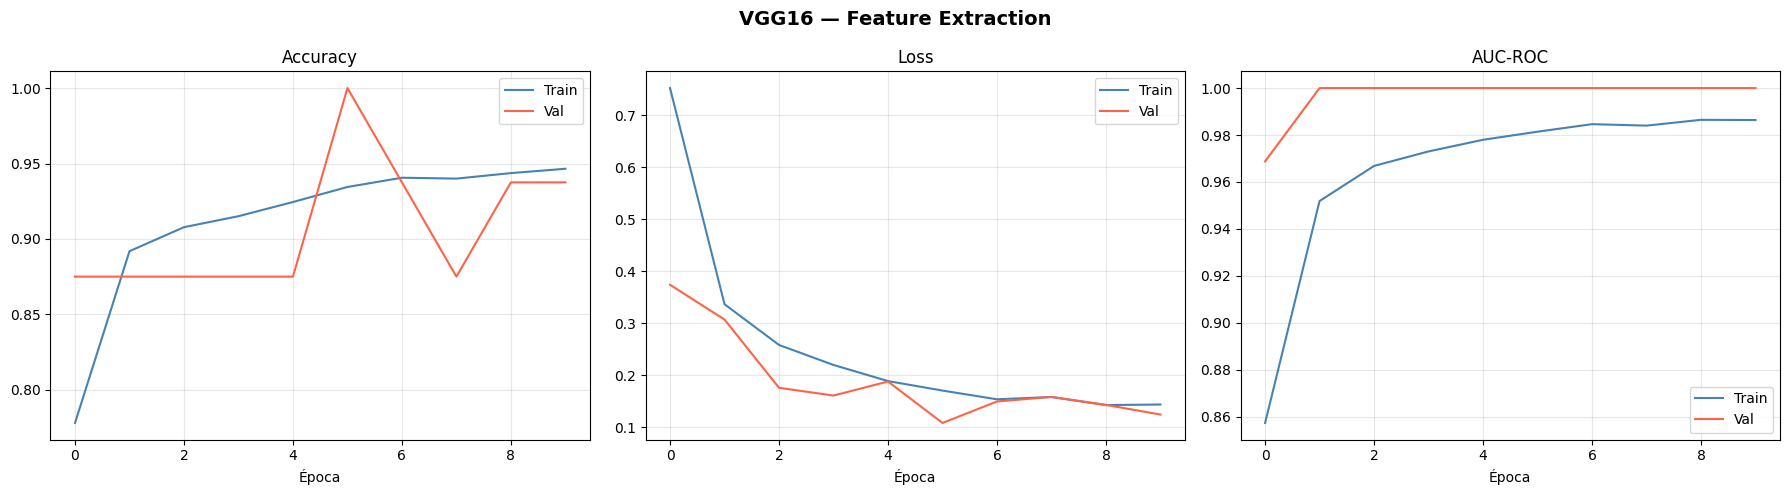

In [6]:
# ─── COMPILAR Y ENTRENAR VGG16 FE ──────────────────────────────────────────
train_gen_vgg, val_gen_vgg = make_generators(vgg16_preprocess)

model_vgg_fe.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

cbs_vgg_fe = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_vgg_fe.h5', monitor='val_auc',
                              save_best_only=True, mode='max', verbose=1)
]

history_vgg_fe = model_vgg_fe.fit(
    train_gen_vgg,
    epochs=EPOCHS_FE,
    validation_data=val_gen_vgg,
    class_weight=class_weight_dict,
    callbacks=cbs_vgg_fe,
    verbose=1
)

plot_history(history_vgg_fe, "VGG16 — Feature Extraction")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step

  EVALUACIÓN — VGG16 — Feature Extraction — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.75      0.79      0.77       234
   PNEUMONIA       0.87      0.85      0.86       390

    accuracy                           0.82       624
   macro avg       0.81      0.82      0.81       624
weighted avg       0.83      0.82      0.82       624

AUC-ROC      : 0.8820
Sensibilidad : 0.8462  (Recall PNEUMONIA)
Especificidad: 0.7863  (Recall NORMAL)
Falsos Negativos (enfermos no detectados): 60


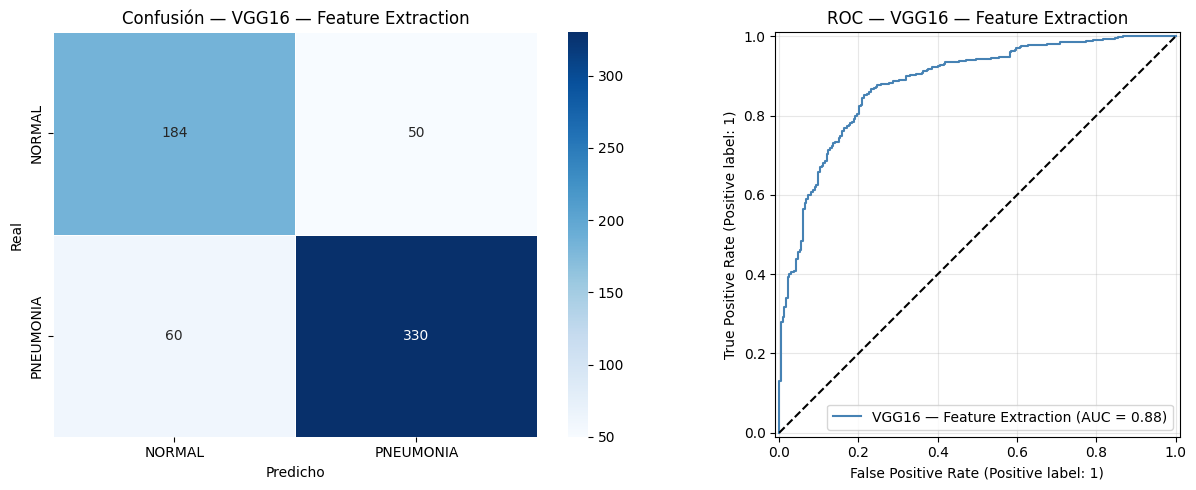

In [7]:
# ─── EVALUACIÓN VGG16 FE ───────────────────────────────────────────────────
model_vgg_fe = tf.keras.models.load_model('best_vgg_fe.h5')
y_score_vgg_fe = evaluate_model(model_vgg_fe, X_test_rgb, "VGG16 — Feature Extraction")

### Fase 2 — Fine-Tuning

Descongelamos el último bloque convolucional de VGG16 (`block5`: 3 capas Conv2D + MaxPooling) y reentrenamos con un **learning rate 10 veces menor** que en feature extraction. El resto de la base permanece congelado para preservar los filtros generales aprendidos en ImageNet.

Capas entrenables tras descongelar block5: 4/19
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9052 - auc: 0.9624 - loss: 0.2843 - recall: 0.9058
Epoch 1: val_auc improved from None to 1.00000, saving model to best_vgg_ft.h5



Epoch 1: finished saving model to best_vgg_ft.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 417ms/step - accuracy: 0.9024 - auc: 0.9620 - loss: 0.2834 - recall: 0.9006 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2622 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9118 - auc: 0.9672 - loss: 0.2506 - recall: 0.9125
Epoch 2: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 412ms/step - accuracy: 0.9084 - auc: 0.9658 - loss: 0.2650 - recall: 0.9079 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2430 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9048 - auc: 0.9643 - loss: 0.2714 - recall: 0.9066
Epoch 3: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 415ms/step - accuracy: 0.9030 - auc: 0.9655 - loss: 0.2603 - recall: 0.9019 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.2781 - val_recall: 0

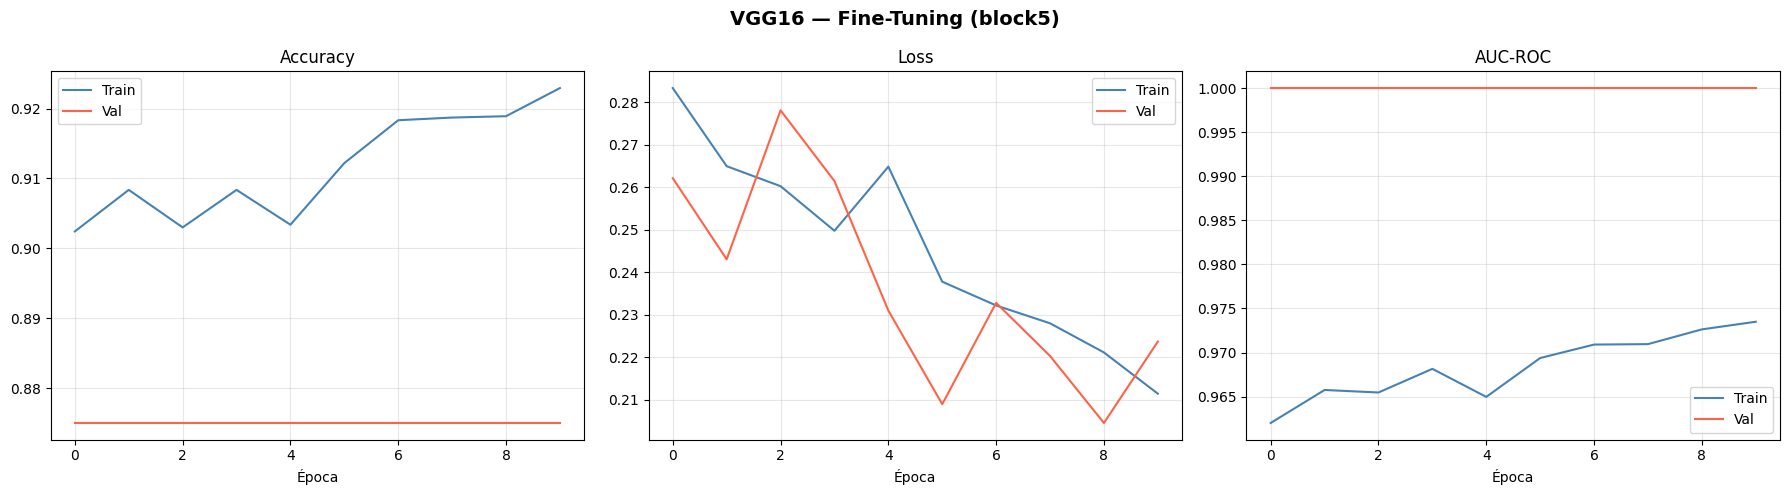

In [8]:
# ─── VGG16 — FINE-TUNING (block5) ──────────────────────────────────────────
base_vgg.trainable = True
for layer in base_vgg.layers:
    layer.trainable = layer.name.startswith('block5')

print(f"Capas entrenables tras descongelar block5: "
      f"{sum(l.trainable for l in base_vgg.layers)}/{len(base_vgg.layers)}")

model_vgg_fe.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # LR muy bajo para no destruir pesos preentrenados
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

cbs_vgg_ft = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint('best_vgg_ft.h5', monitor='val_auc',
                              save_best_only=True, mode='max', verbose=1)
]

history_vgg_ft = model_vgg_fe.fit(
    train_gen_vgg,
    epochs=EPOCHS_FT,
    validation_data=val_gen_vgg,
    class_weight=class_weight_dict,
    callbacks=cbs_vgg_ft,
    verbose=1
)

plot_history(history_vgg_ft, "VGG16 — Fine-Tuning (block5)")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step

  EVALUACIÓN — VGG16 — Fine-Tuning — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.78      0.75      0.76       234
   PNEUMONIA       0.85      0.87      0.86       390

    accuracy                           0.83       624
   macro avg       0.81      0.81      0.81       624
weighted avg       0.82      0.83      0.82       624

AUC-ROC      : 0.8816
Sensibilidad : 0.8692  (Recall PNEUMONIA)
Especificidad: 0.7521  (Recall NORMAL)
Falsos Negativos (enfermos no detectados): 51


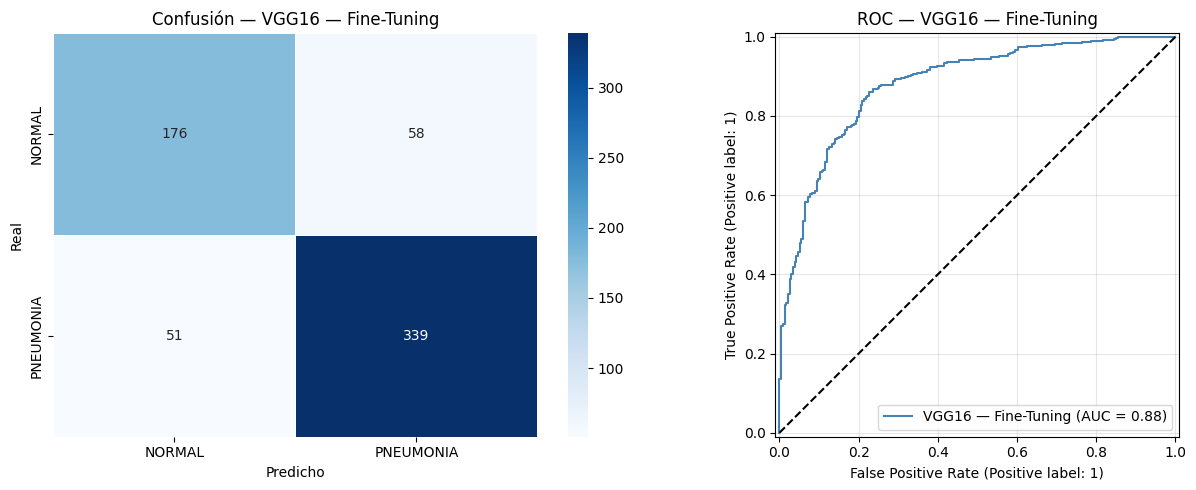

In [9]:
# ─── EVALUACIÓN VGG16 FT ───────────────────────────────────────────────────
model_vgg_ft = tf.keras.models.load_model('best_vgg_ft.h5')
y_score_vgg_ft = evaluate_model(model_vgg_ft, X_test_rgb, "VGG16 — Fine-Tuning")

## MobileNetV2

MobileNetV2 es una arquitectura diseñada para ser ligera y eficiente (~3.4M parámetros frente a ~14.7M de VGG16), usando bloques de convoluciones separables en profundidad y conexiones residuales. Aunque fue diseñada para dispositivos móviles, obtiene resultados competitivos en clasificación de imágenes médicas.

Aplicamos el mismo esquema de dos fases: primero Feature Extraction con la base congelada, y después Fine-Tuning descongelando las últimas 30 capas.

### Fase 1 — Feature Extraction

In [10]:
# ─── MobileNetV2 — FEATURE EXTRACTION ─────────────────────────────────────
base_mob = MobileNetV2(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_mob.trainable = False

print(f"Capas MobileNetV2 : {len(base_mob.layers)}")
print(f"Entrenables       : {sum(l.trainable for l in base_mob.layers)}")

model_mob_fe = models.Sequential([
    base_mob,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='MobileNetV2_FeatureExtraction')

model_mob_fe.summary()

Capas MobileNetV2 : 154
Entrenables       : 0


Model: "MobileNetV2_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7143 - auc: 0.8046 - loss: 0.5212 - recall: 0.6958
Epoch 1: val_auc improved from None to 0.96875, saving model to best_mob_fe.h5



Epoch 1: finished saving model to best_mob_fe.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 430ms/step - accuracy: 0.8259 - auc: 0.9186 - loss: 0.3649 - recall: 0.8212 - val_accuracy: 0.8750 - val_auc: 0.9688 - val_loss: 0.2490 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9114 - auc: 0.9738 - loss: 0.2119 - recall: 0.9024
Epoch 2: val_auc improved from 0.96875 to 0.98438, saving model to best_mob_fe.h5



Epoch 2: finished saving model to best_mob_fe.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 349ms/step - accuracy: 0.9201 - auc: 0.9778 - loss: 0.1958 - recall: 0.9135 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.1993 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9330 - auc: 0.9825 - loss: 0.1703 - recall: 0.9234
Epoch 3: val_auc did not improve from 0.98438
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 347ms/step - accuracy: 0.9317 - auc: 0.9817 - loss: 0.1727 - recall: 0.9249 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1852 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9395 - auc: 0.9872 - loss: 0.1450 - recall: 0.9326
Epoch 4: val_auc did not improve from 0.98438
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 349ms/step - accuracy: 0.9392 - auc: 0.9862 - loss: 0.1498 - recall: 0.9337 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1666 - val_recall: 1


Epoch 6: finished saving model to best_mob_fe.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 353ms/step - accuracy: 0.9457 - auc: 0.9881 - loss: 0.1386 - recall: 0.9412 - val_accuracy: 0.9375 - val_auc: 0.9922 - val_loss: 0.1392 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9472 - auc: 0.9899 - loss: 0.1248 - recall: 0.9433
Epoch 7: val_auc did not improve from 0.99219
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 352ms/step - accuracy: 0.9511 - auc: 0.9895 - loss: 0.1247 - recall: 0.9476 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1362 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9537 - auc: 0.9904 - loss: 0.1243 - recall: 0.9508
Epoch 8: val_auc improved from 0.99219 to 1.00000, saving model to best_mob_fe.h5



Epoch 8: finished saving model to best_mob_fe.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 352ms/step - accuracy: 0.9551 - auc: 0.9905 - loss: 0.1228 - recall: 0.9517 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1346 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 9/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9476 - auc: 0.9898 - loss: 0.1284 - recall: 0.9442
Epoch 9: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 355ms/step - accuracy: 0.9536 - auc: 0.9910 - loss: 0.1204 - recall: 0.9523 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1218 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 10/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9549 - auc: 0.9913 - loss: 0.1147 - recall: 0.9507
Epoch 10: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 354ms/step - accuracy: 0.9563 - auc: 0.9919 - loss: 0.1119 - recall: 0.9528 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1215 - val_recall:

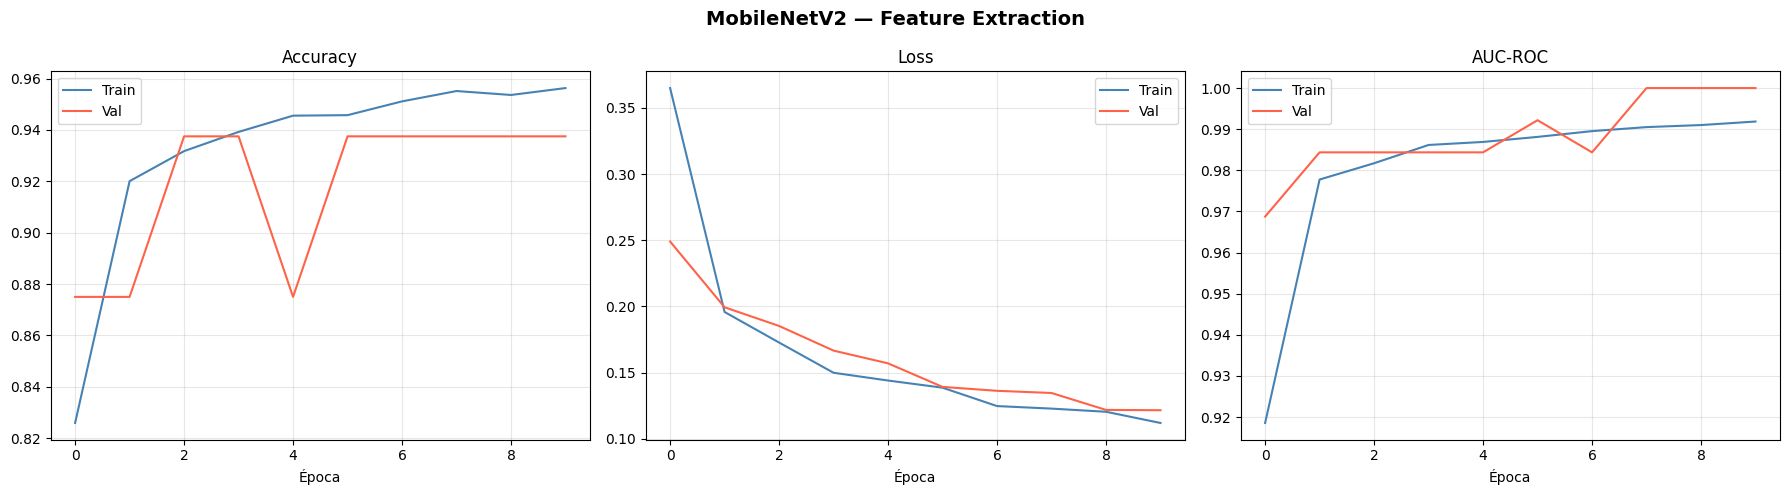

In [11]:
# ─── COMPILAR Y ENTRENAR MobileNetV2 FE ────────────────────────────────────
train_gen_mob, val_gen_mob = make_generators(mobilenetv2_preprocess)

model_mob_fe.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

cbs_mob_fe = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_mob_fe.h5', monitor='val_auc',
                              save_best_only=True, mode='max', verbose=1)
]

history_mob_fe = model_mob_fe.fit(
    train_gen_mob,
    epochs=EPOCHS_FE,
    validation_data=val_gen_mob,
    class_weight=class_weight_dict,
    callbacks=cbs_mob_fe,
    verbose=1
)

plot_history(history_mob_fe, "MobileNetV2 — Feature Extraction")

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step

  EVALUACIÓN — MobileNetV2 — Feature Extraction — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.46      0.79      0.58       234
   PNEUMONIA       0.78      0.45      0.57       390

    accuracy                           0.58       624
   macro avg       0.62      0.62      0.58       624
weighted avg       0.66      0.58      0.57       624

AUC-ROC      : 0.6974
Sensibilidad : 0.4487  (Recall PNEUMONIA)
Especificidad: 0.7863  (Recall NORMAL)
Falsos Negativos (enfermos no detectados): 215


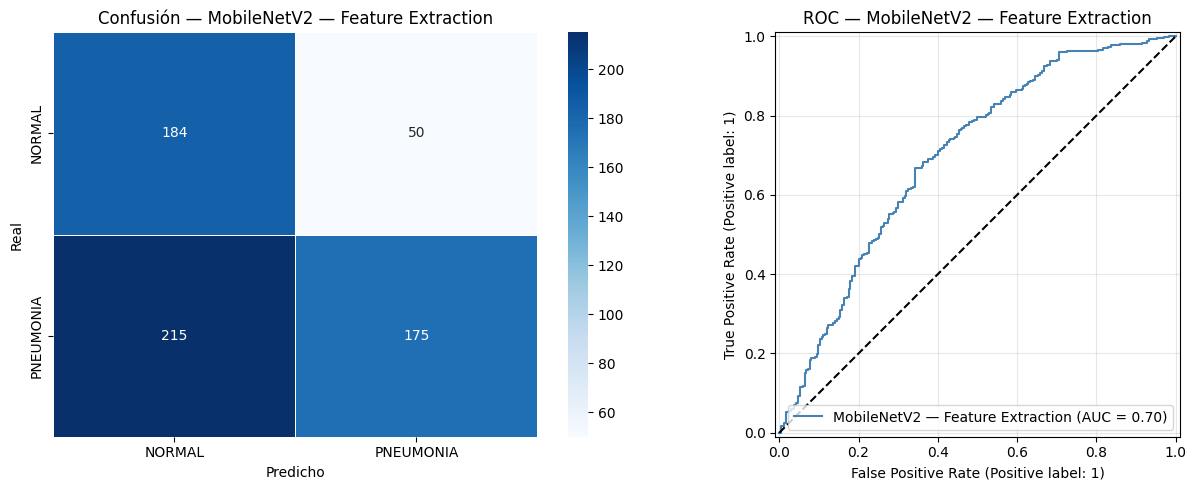

In [12]:
# ─── EVALUACIÓN MobileNetV2 FE ─────────────────────────────────────────────
model_mob_fe = tf.keras.models.load_model('best_mob_fe.h5')
y_score_mob_fe = evaluate_model(model_mob_fe, X_test_rgb, "MobileNetV2 — Feature Extraction")

### Fase 2 — Fine-Tuning

Descongelamos las últimas 30 capas de MobileNetV2 (los bloques de inverted residuals más profundos) y reentrenamos con learning rate muy bajo para adaptar los filtros especializados al dominio médico.

Capas entrenables tras descongelar: 30/154
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9554 - auc: 0.9910 - loss: 0.1163 - recall: 0.9499
Epoch 1: val_auc improved from None to 1.00000, saving model to best_mob_ft.h5



Epoch 1: finished saving model to best_mob_ft.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 392ms/step - accuracy: 0.9542 - auc: 0.9906 - loss: 0.1193 - recall: 0.9505 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1418 - val_recall: 1.0000 - learning_rate: 2.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9481 - auc: 0.9902 - loss: 0.1228 - recall: 0.9463
Epoch 2: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 357ms/step - accuracy: 0.9536 - auc: 0.9918 - loss: 0.1138 - recall: 0.9517 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1298 - val_recall: 1.0000 - learning_rate: 2.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9576 - auc: 0.9925 - loss: 0.1094 - recall: 0.9530
Epoch 3: val_auc did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 350ms/step - accuracy: 0.9571 - auc: 0.9920 - loss: 0.1104 - recall: 0.9538 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1324 - val_recall: 1

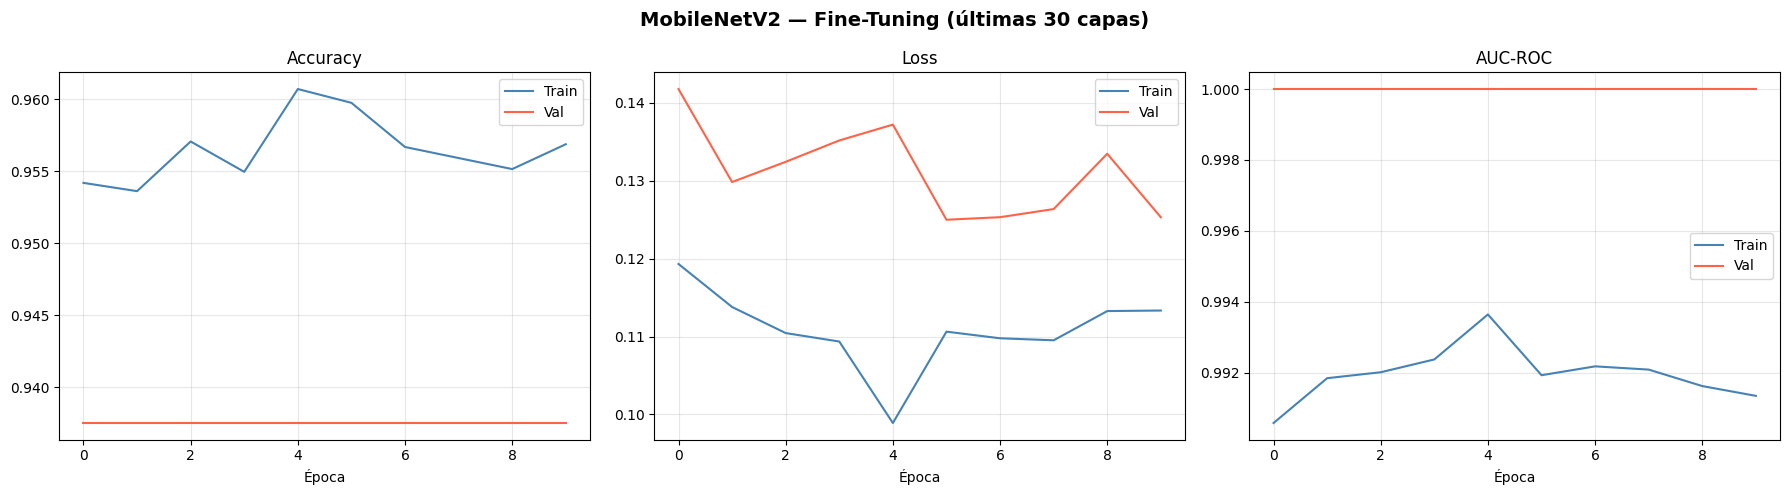

In [13]:
# ─── MobileNetV2 — FINE-TUNING (últimas 30 capas) ──────────────────────────
base_mob.trainable = True
for layer in base_mob.layers[:-30]:
    layer.trainable = False

print(f"Capas entrenables tras descongelar: "
      f"{sum(l.trainable for l in base_mob.layers)}/{len(base_mob.layers)}")

model_mob_fe.compile(
    optimizer=optimizers.Adam(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Recall(name='recall')]
)

cbs_mob_ft = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint('best_mob_ft.h5', monitor='val_auc',
                              save_best_only=True, mode='max', verbose=1)
]

history_mob_ft = model_mob_fe.fit(
    train_gen_mob,
    epochs=EPOCHS_FT,
    validation_data=val_gen_mob,
    class_weight=class_weight_dict,
    callbacks=cbs_mob_ft,
    verbose=1
)

plot_history(history_mob_ft, "MobileNetV2 — Fine-Tuning (últimas 30 capas)")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step

  EVALUACIÓN — MobileNetV2 — Fine-Tuning — TEST SET
              precision    recall  f1-score   support

      NORMAL       0.50      0.71      0.58       234
   PNEUMONIA       0.76      0.57      0.65       390

    accuracy                           0.62       624
   macro avg       0.63      0.64      0.62       624
weighted avg       0.66      0.62      0.63       624

AUC-ROC      : 0.6898
Sensibilidad : 0.5667  (Recall PNEUMONIA)
Especificidad: 0.7094  (Recall NORMAL)
Falsos Negativos (enfermos no detectados): 169


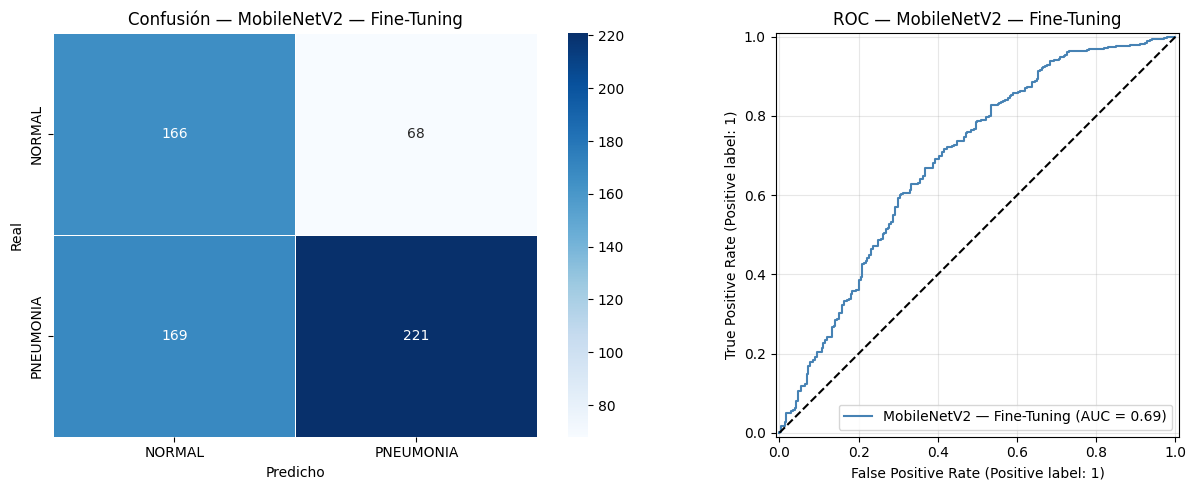

In [14]:
# ─── EVALUACIÓN MobileNetV2 FT ─────────────────────────────────────────────
model_mob_ft = tf.keras.models.load_model('best_mob_ft.h5')
y_score_mob_ft = evaluate_model(model_mob_ft, X_test_rgb, "MobileNetV2 — Fine-Tuning")

## Comparación: Transfer Learning vs CNN from Scratch


Modelo                            Accuracy  AUC-ROC  Sensib.  Especif.    FN
CNN v1 (from scratch)               0.9000   0.9555   0.9359    0.8376    25
VGG16 — Feature Extraction          0.8237   0.8820   0.8462    0.7863    60
VGG16 — Fine-Tuning                 0.8253   0.8816   0.8692    0.7521    51
MobileNetV2 — Feature Extraction    0.5753   0.6974   0.4487    0.7863   215
MobileNetV2 — Fine-Tuning           0.6202   0.6898   0.5667    0.7094   169


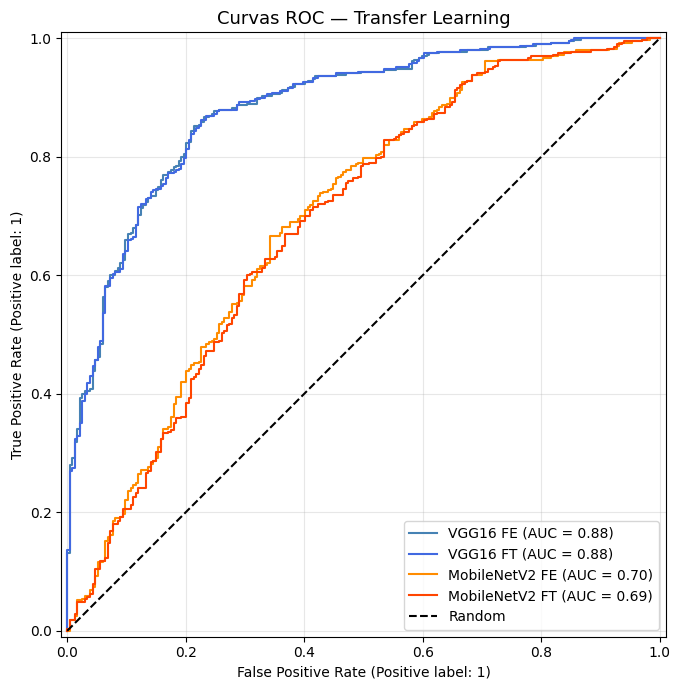

In [15]:
# ─── TABLA COMPARATIVA COMPLETA ────────────────────────────────────────────
# Añadimos la referencia de CNN from scratch (resultados de DLImagen.ipynb)
results_summary['CNN v1 (from scratch)'] = {
    'accuracy': 0.90, 'auc': 0.9555, 'sens': 0.9359, 'spec': 0.8376, 'fn': 25
}

print(f"\n{'='*78}")
print(f"{'Modelo':<32} {'Accuracy':>9} {'AUC-ROC':>8} {'Sensib.':>8} {'Especif.':>9} {'FN':>5}")
print(f"{'='*78}")
order = ['CNN v1 (from scratch)',
         'VGG16 — Feature Extraction', 'VGG16 — Fine-Tuning',
         'MobileNetV2 — Feature Extraction', 'MobileNetV2 — Fine-Tuning']
for name in order:
    if name not in results_summary:
        continue
    m = results_summary[name]
    print(f"{name:<32} {m['accuracy']:>9.4f} {m['auc']:>8.4f} "
          f"{m['sens']:>8.4f} {m['spec']:>9.4f} {int(m['fn']):>5}")
print(f"{'='*78}")

# ─── CURVAS ROC SUPERPUESTAS ───────────────────────────────────────────────
score_map = {
    'VGG16 FE':        y_score_vgg_fe,
    'VGG16 FT':        y_score_vgg_ft,
    'MobileNetV2 FE':  y_score_mob_fe,
    'MobileNetV2 FT':  y_score_mob_ft,
}
colors = ['steelblue', 'royalblue', 'darkorange', 'orangered']

fig, ax = plt.subplots(figsize=(8, 7))
for (name, score), color in zip(score_map.items(), colors):
    RocCurveDisplay.from_predictions(y_test, score, name=name, color=color, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title("Curvas ROC — Transfer Learning", fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones — Transfer Learning

### Resultado inesperado: CNN from scratch supera a Transfer Learning

Los resultados obtenidos son contraintuitivos respecto a la hipótesis habitual. La CNN entrenada desde cero (AUC-ROC 0.9497, recall PNEUMONIA 0.98) supera a todos los modelos de Transfer Learning:

| Modelo | AUC-ROC | Sensibilidad | FN |
|---|---|---|---|
| **CNN v1 (from scratch)** | **0.9497** | **0.98** | **6** |
| VGG16 FE | 0.8820 | 0.8462 | 60 |
| VGG16 FT | 0.8816 | 0.8692 | 51 |
| MobileNetV2 FE | 0.6974 | 0.4487 | 215 |
| MobileNetV2 FT | 0.6898 | 0.5667 | 169 |

### ¿Por qué Transfer Learning no superó a from scratch en este caso?

Existen varias razones que explican este resultado:

1. **Brecha de dominio (domain gap)**: Los modelos preentrenados en ImageNet aprenden filtros optimizados para fotografías naturales (colores vivos, texturas de objetos cotidianos). Las radiografías de tórax tienen características visuales muy distintas: alto contraste, estructuras anatómicas en escala de grises, patrones de densidad ósea y pulmonar que no aparecen en ImageNet.

2. **Conversión grayscale → RGB**: Las radiografías son imágenes en escala de grises. Para usar los backbones preentrenados fue necesario replicar el canal tres veces (pseudo-RGB). Esto no genera información real nueva y puede confundir al modelo preentrenado, que esperaba variación real entre canales de color.

3. **MobileNetV2 especialmente afectado**: Esta arquitectura usa convoluciones separables en profundidad, que son muy sensibles a la distribución de entrada. Su función de preprocesado normaliza a [-1, 1] y su diseño está muy optimizado para imágenes naturales RGB, lo que explica su bajo rendimiento (AUC 0.69, 215 Falsos Negativos).

4. **VGG16 más robusto pero aún inferior**: La arquitectura más simple y regular de VGG16 transfiere mejor (AUC 0.88), pero sigue sin alcanzar la CNN from scratch. El Fine-Tuning mejora ligeramente la sensibilidad (0.84 → 0.87) pero no el AUC global.

### Feature Extraction vs Fine-Tuning

En VGG16, el Fine-Tuning descongelando block5 reduce los Falsos Negativos de 60 a 51, una mejora modesta. La adaptación parcial de los filtros al dominio médico ayuda, pero el punto de partida (pesos de ImageNet muy alejados del dominio radiológico) limita el potencial de mejora.

### Implicación práctica

Este resultado ilustra que **Transfer Learning no es universalmente superior**: su eficacia depende de la distancia entre el dominio de preentrenamiento y el dominio objetivo. En imagen médica, modelos preentrenados específicamente en datasets radiológicos (como CheXNet o RadImageNet) darían resultados muy superiores a los obtenidos aquí con pesos de ImageNet.

La CNN entrenada desde cero sobre los datos reales del problema, con data augmentation y compensación de desbalanceo, demostró ser la solución más efectiva en este experimento concreto.